# 02 · ResNet-18 baseline (Baseline 1)

**Goal:** a small, fast CNN baseline.

The training code lives in `src/common.py` so every model is trained and scored the same way.

## 1. Project folder

In [1]:
# Run this cell first, every time you open the notebook.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:                       # Google Colab
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/MalariaScanAI")  # where you unzipped the project
else:                                                   # your own laptop
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)

Project folder: c:\Users\VOTHY VYSAL\Documents\MalariaScanAI


## 2. Environment, GPU and dataset

In [2]:
from src.common import *

set_seed(42)
print_environment()

Python : 3.13.14
PyTorch: 2.14.1+cu126
CUDA available: True
Device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB
train images: 19363
val images: 4323
test images: 3872
Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']


## 3. Train

ImageNet weights, new classification head, all layers trained with AdamW (learning rate 1e-4), no augmentation, no scheduler. The parameter counts are calculated from the real model and printed first. The best checkpoint (highest validation Macro-F1) is saved, and training stops early if validation stops improving.

Out of GPU memory? Change `batch_size` to 8. Short on time? Lower `epochs`.

In [5]:
info = train("resnet18", epochs=15, patience=3, batch_size=16)

resnet18
Total parameters:         11,177,538
Trainable parameters:     11,177,538
Non-trainable parameters: 0

Epoch 1/15
Train Loss: 0.133
Train Accuracy: 95.40%
Val Loss: 0.152
Val Accuracy: 94.91%
Val Macro-F1: 94.69%
Time: 97.7 sec

Epoch 2/15
Train Loss: 0.094
Train Accuracy: 96.76%
Val Loss: 0.118
Val Accuracy: 95.51%
Val Macro-F1: 95.28%
Time: 96.8 sec

Epoch 3/15
Train Loss: 0.079
Train Accuracy: 97.30%
Val Loss: 0.123
Val Accuracy: 95.49%
Val Macro-F1: 95.29%
Time: 95.9 sec

Epoch 4/15
Train Loss: 0.063
Train Accuracy: 97.84%
Val Loss: 0.137
Val Accuracy: 95.60%
Val Macro-F1: 95.37%
Time: 95.8 sec

Epoch 5/15
Train Loss: 0.054
Train Accuracy: 98.09%
Val Loss: 0.132
Val Accuracy: 95.44%
Val Macro-F1: 95.24%
Time: 96.6 sec

Epoch 6/15
Train Loss: 0.039
Train Accuracy: 98.67%
Val Loss: 0.151
Val Accuracy: 95.72%
Val Macro-F1: 95.50%
Time: 97.0 sec

Epoch 7/15
Train Loss: 0.032
Train Accuracy: 98.76%
Val Loss: 0.188
Val Accuracy: 94.98%
Val Macro-F1: 94.76%
Time: 96.1 sec

Epoch 

## 4. Training curves

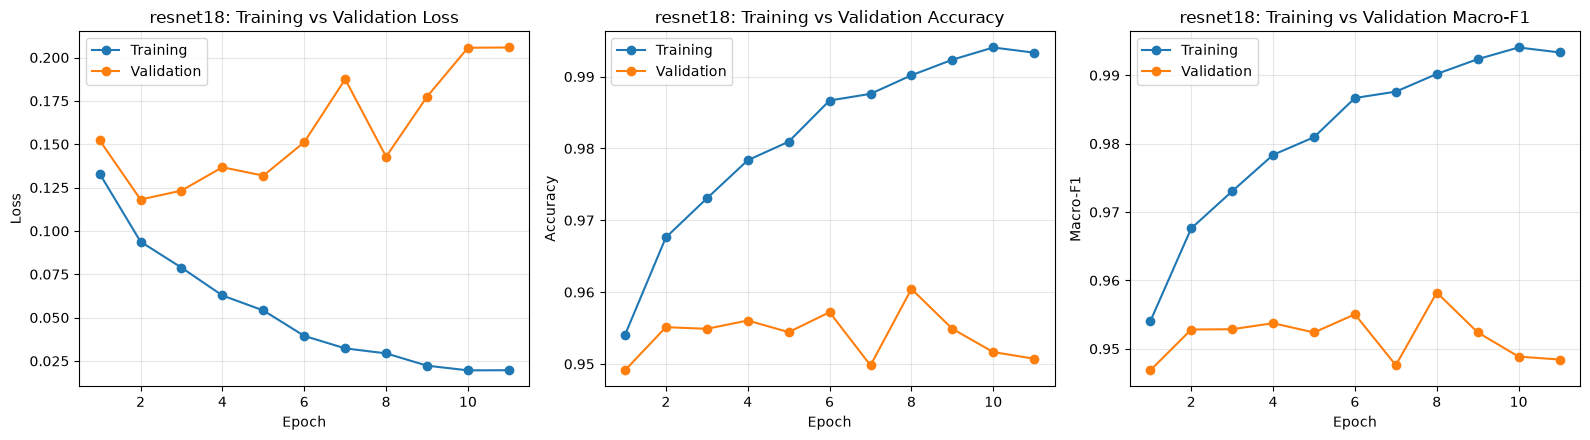

In [6]:
plot_history("resnet18")

## 5. Test results

In [ ]:
metrics, cm, classes, report = evaluate("resnet18")
for k in ("accuracy", "precision", "recall", "macro_f1"):
    print(f"Test {k}: {metrics[k] * 100:.2f}%")
print()
print(report)

Test accuracy: 97.13%
Test precision: 96.90%
Test recall: 97.03%
Test macro_f1: 96.97%

              precision    recall  f1-score   support

 PARASITIZED       0.96      0.97      0.96      1477
  UNINFECTED       0.98      0.97      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.97      0.97      0.97      3872
weighted avg       0.97      0.97      0.97      3872



: 